# LAUGEN demo: one image in, a sequence out

This notebook shows LAUGEN turning a **single** frame into a synthetic longitudinal
sequence. LAUGEN does not transform an existing sequence — it synthesizes one from scratch, guided
by the frame's own segmentation mask. Everything here runs on CPU in well under a minute, no
checkpoints or downloads required — the input frame below is a synthetic blob generated in this
notebook (no imaging data is bundled), so the mechanism is visible without shipping a dataset.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from laugen import deform_structure

np.random.seed(0)

## 1. Generate a toy sample

A synthetic frame plus its "structure" segmentation, generated inline — swap this cell for your
own `(img, seg)` numpy arrays (or a real ACDC frame) to see LAUGEN on real anatomy.


In [2]:
D, H, W = 24, 96, 96
zz, yy, xx = np.mgrid[0:D, 0:H, 0:W]
center = np.array([D / 2, H / 2, W / 2])
radius_img = min(D, H, W) * 0.28
radius_seg = radius_img * 0.7
dist = np.sqrt((zz - center[0]) ** 2 + (yy - center[1]) ** 2 + (xx - center[2]) ** 2)

img = np.clip(1.0 - dist / radius_img, 0, 1).astype(np.float32)
img += 0.03 * np.random.randn(D, H, W).astype(np.float32)
img = np.clip(img, 0, 1).astype(np.float32)
seg = (dist < radius_seg).astype(np.float32)

print("img:", img.shape, img.dtype, "seg:", seg.shape, seg.dtype)


img: (24, 96, 96) float32 seg: (24, 96, 96) float32


## 2. Visualize the input

A single mid-depth slice of the one frame LAUGEN will expand into a sequence.

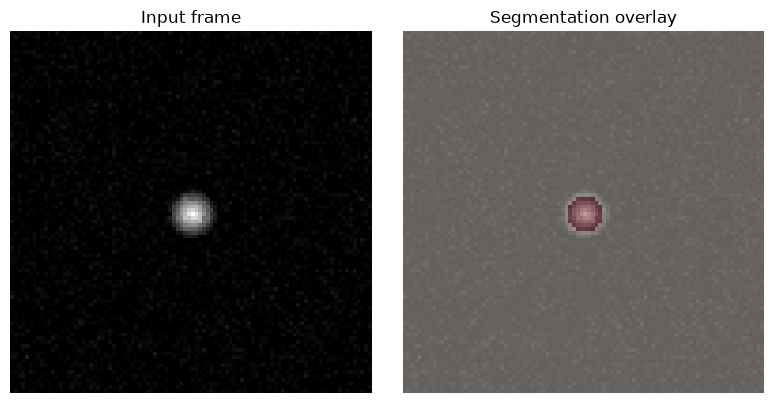

In [3]:
mid = img.shape[0] // 2
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img[mid], cmap="gray")
axes[0].set_title("Input frame")
axes[0].axis("off")
axes[1].imshow(img[mid], cmap="gray")
axes[1].imshow(seg[mid], cmap="Reds", alpha=0.4)
axes[1].set_title("Segmentation overlay")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 3. Generate a sequence with default parameters

`deform_structure` displaces the image along the segmentation-boundary gradient, scaled over a
time axis — a single call turns the one frame above into a full sequence.

In [ ]:
def to_gif(seq, path, fps=4):
    import os
    import imageio
    dirname = os.path.dirname(path)
    if dirname:
        os.makedirs(dirname, exist_ok=True)
    mid = seq.shape[1] // 2
    frames = []
    for t in range(seq.shape[0]):
        sl = seq[t, mid]
        sl = (sl - sl.min()) / (sl.max() - sl.min() + 1e-8)
        frames.append((sl * 255).astype(np.uint8))
    imageio.mimsave(path, frames, fps=fps, loop=0)

time_points = np.linspace(0, 1, 10, dtype=np.float32)
seq_default = deform_structure(img, seg, time_points, intensity=8.0, growth_max=4.0,
                                target_shape=img.shape, apply_prob=0.6, n_blobs=2)
print("sequence:", seq_default.shape)

to_gif(seq_default, "assets/demo_default.gif")
display(Image(filename="assets/demo_default.gif"))

## 4. Vary the main parameters — the same frame, three different futures

`intensity` (deformation amplitude) and `growth_max` (upper multiplier on that amplitude) are the
two main controllable knobs. Same input frame, three settings, three distinct plausible
trajectories.

mild -> intensity = 3.0 , growth_max = 2.0


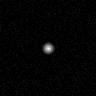

moderate -> intensity = 8.0 , growth_max = 4.0


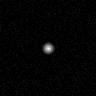

aggressive -> intensity = 16.0 , growth_max = 6.0


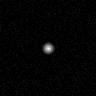

In [5]:
settings = [
    {"label": "mild", "intensity": 3.0, "growth_max": 2.0},
    {"label": "moderate", "intensity": 8.0, "growth_max": 4.0},
    {"label": "aggressive", "intensity": 16.0, "growth_max": 6.0},
]

for cfg in settings:
    np.random.seed(1)
    seq = deform_structure(img, seg, time_points, intensity=cfg["intensity"],
                            growth_max=cfg["growth_max"], target_shape=img.shape,
                            apply_prob=0.6, n_blobs=2)
    path = f"assets/demo_{cfg['label']}.gif"
    to_gif(seq, path)
    print(cfg["label"], "-> intensity =", cfg["intensity"], ", growth_max =", cfg["growth_max"])
    display(Image(filename=path))

## 5. Drop-in as a torch `Dataset`

LAUGEN's output is a plain `(T, *spatial)` numpy array — directly usable as a training sample,
with no other glue code needed.

In [6]:
import torch
from torch.utils.data import Dataset


class LaugenSyntheticDataset(Dataset):
    """Wraps a single (img, seg) pair, generating a fresh synthetic sequence per __getitem__."""

    def __init__(self, img, seg, time_points, **deform_kwargs):
        self.img, self.seg = img, seg
        self.time_points = time_points
        self.deform_kwargs = deform_kwargs

    def __len__(self):
        return 1  # a single base image can back arbitrarily many synthetic sequences

    def __getitem__(self, idx):
        seq = deform_structure(self.img, self.seg, self.time_points, **self.deform_kwargs)
        return torch.from_numpy(seq).unsqueeze(1)  # (T, C=1, *spatial)


ds = LaugenSyntheticDataset(img, seg, time_points, intensity=8.0, growth_max=4.0, target_shape=img.shape)
sample = ds[0]
print("dataset sample shape:", sample.shape, sample.dtype)

dataset sample shape: torch.Size([10, 1, 24, 96, 96]) torch.float32


## Links

- Parent repo: [Longitudinal4DMed](https://github.com/MIC-DKFZ/Longitudinal4DMed)
- [Temporal Flow Matching](https://arxiv.org/abs/2508.21580)
- [CRONOS](https://arxiv.org/abs/2512.16577)